# CNN Regression on the Max Displacement Image Dataset

This notebook is written as a guided walkthrough for first-time learners, using `inclass_examples/data/image/global_features/` to solve a continuous regression task from 32x32 grayscale images. You will predict structural response (`max_disp`) directly from rasterized geometry images, compare a simple linear pixel baseline against a small CNN, and keep the same evaluation habits from the MLP regression notebook.

Learning goals are embedded directly in the flow: by the end, you should be able to inspect image dataset quality, reason about target distribution, visualize example images, use PCA and t-SNE for intuition in image space, split data without leakage, normalize image tensors correctly, train a small CNN with early stopping, and interpret MAE, RMSE, R^2, and residual plots in plain language.

## 1. Imports + Reproducibility Seed

Before touching the dataset, we set up the environment so the notebook behaves predictably. Reproducibility matters in CNN workflows too: random weight initialization, random train/validation/test splits, and shuffled mini-batches can move the final metrics enough to confuse beginners. Fixing the seed makes comparisons much easier to trust.

The toolchain stays close to the MLP notebook: `pandas` for tabular metadata, `matplotlib/seaborn` for visualization, `scikit-learn` for splitting, geometry projection, and baseline modeling, and `keras` for the convolutional neural network.

In [1]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style="whitegrid")
print(f"Seed fixed to {SEED} for Python, NumPy, and TensorFlow.")

Seed fixed to 42 for Python, NumPy, and TensorFlow.


## 2. Load Dataset

This dataset has two parts that must stay aligned: a CSV file with sample metadata and targets, and a folder of grayscale PNG images named by sample index. In this notebook, the regression target is chosen with `target_col`, the image filenames come from `index_col`, and the remaining scalar columns can be isolated by dropping those non-feature columns from the CSV. The scalar columns remain useful for bookkeeping and optional comparison later, but they are not fed into the CNN.

This notebook assumes it is run from `inclass_examples/notebooks/`, so the dataset path is set directly with `Path("../data/image/global_features")`.

In [2]:
DATA_DIR = Path("../data/image/global_features")
CSV_PATH = DATA_DIR / "global_features_scalar_dataset.csv"
IMG_SIZE = (32, 32)
target_col = "max_disp"
index_col = "index"

if not CSV_PATH.exists():
    raise FileNotFoundError(f"Could not find dataset CSV at: {CSV_PATH.resolve()}")

df = pd.read_csv(CSV_PATH)

required_cols = {index_col, target_col}
missing_required = required_cols.difference(df.columns)
if missing_required:
    raise ValueError(f"Dataset is missing required columns: {sorted(missing_required)}")

df = df.sort_values(index_col).reset_index(drop=True)
scalar_feature_df = df.drop(columns=[index_col, target_col]).copy()
scalar_feature_cols = scalar_feature_df.columns.tolist()
y = df[target_col].astype("float32").copy()

image_paths = [DATA_DIR / f"{int(idx):06d}.png" for idx in df[index_col]]
missing_image_paths = [str(path) for path in image_paths if not path.exists()]
if missing_image_paths:
    preview = missing_image_paths[:5]
    raise FileNotFoundError(
        f"Missing {len(missing_image_paths)} image files. First few: {preview}"
    )

X_img_raw = np.stack([
    keras.utils.img_to_array(
        keras.utils.load_img(path, color_mode="grayscale", target_size=IMG_SIZE)
    )
    for path in image_paths
]).astype("float32")

print(f"Loaded file: {CSV_PATH.resolve()}")
print(f"Rows: {len(df):,} | Images: {len(image_paths):,}")
print(f"Image tensor shape: {X_img_raw.shape}")
print(f"Scalar feature columns retained separately: {len(scalar_feature_cols)}")
print(f"Target summary -> min: {y.min():.3f}, mean: {y.mean():.3f}, max: {y.max():.3f}")
print()
print("First 5 rows:")
display(df.head())

Loaded file: C:\Users\Ozguc\Documents\GitHub\CMDO-ML\inclass_examples\data\image\global_features\global_features_scalar_dataset.csv
Rows: 10,000 | Images: 10,000
Image tensor shape: (10000, 32, 32, 1)
Scalar feature columns retained separately: 3
Target summary -> min: 4.270, mean: 84.830, max: 163.278

First 5 rows:


,index,x_00,x_01,x_02,max_disp
0,0,9.591402,0.375161,-2.249707,138.680797
1,1,3.348161,11.047068,1.766995,50.449599
2,2,13.382694,1.304082,-0.780782,158.513901
3,3,0.446958,3.279570,0.053553,162.810292
4,4,0.398040,2.982565,1.498844,65.747812


## 3. Data Quality Check

A fast quality check prevents subtle failures later in the pipeline. Here we run the classical checks for this mixed CSV-plus-image setup: missing values, infinite values, duplicate rows, duplicate sample identifiers, column types, constant scalar features, image alignment, and simple image-integrity summaries. We also show conservative cleaning actions such as converting infinities to missing values, dropping rows with missing targets or remaining missing entries, and removing exact duplicate rows while keeping the image tensor aligned with the cleaned CSV.

When you read this output, focus on five questions. First, are there invalid or missing values in the CSV? Second, are there duplicate rows or repeated identifiers? Third, do the scalar columns still look numeric and informative rather than constant? Fourth, do the CSV rows and image tensors stay aligned after cleaning? Fifth, do the images themselves look plausible rather than blank or corrupted? That will affect how you interpret MAE and RMSE.

In [3]:
# Keep the starting row count so we can report how much cleaning changed the dataset.
rows_before_cleaning = len(df)

# Check 1: look for +/- inf in numeric columns and convert them to NaN so one
# missing-value workflow can handle every invalid numeric entry consistently.
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if numeric_cols:
    infinite_counts = pd.Series(
        np.isinf(df[numeric_cols].to_numpy()).sum(axis=0),
        index=numeric_cols,
    ).sort_values(ascending=False)
else:
    infinite_counts = pd.Series(dtype="int64")
infinite_total = int(infinite_counts.sum()) if not infinite_counts.empty else 0
if infinite_total > 0:
    df = df.replace([np.inf, -np.inf], np.nan)

# Check 2: measure missingness after the inf-to-NaN conversion.
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_total = int(missing_counts.sum())
rows_with_missing = int(df.isna().any(axis=1).sum())
all_missing_scalar_cols = [
    col for col in scalar_feature_cols
    if col in df.columns and df[col].isna().all()
]

# Check 3: surface duplicate rows and duplicate identifiers separately.
duplicate_rows = int(df.duplicated().sum())
duplicate_indices = int(df[index_col].duplicated().sum())

# Check 4: summarize dtypes before modeling so you can confirm the CSV
# still looks numerical and ready to pair with the images.
dtype_summary = (
    df.dtypes.astype(str)
    .value_counts()
    .sort_index()
    .rename_axis("dtype")
    .to_frame("column_count")
)

# Cleaning step 1: drop scalar feature columns that are entirely missing because
# they carry no usable signal and only complicate bookkeeping.
if all_missing_scalar_cols:
    df = df.drop(columns=all_missing_scalar_cols).copy()

# Cleaning step 2: drop rows with missing targets because image regression
# cannot learn from rows that do not have a label.
target_keep_mask = df[target_col].notna().to_numpy()
dropped_missing_target = int((~target_keep_mask).sum())
df = df.loc[target_keep_mask].copy()
X_img_raw = X_img_raw[target_keep_mask]
image_paths = [path for path, keep in zip(image_paths, target_keep_mask) if keep]

# Cleaning step 3: drop rows with any remaining missing values and apply the
# same mask to the image tensor so the two data sources stay aligned.
row_keep_mask = (~df.isna().any(axis=1)).to_numpy()
dropped_missing_rows = int((~row_keep_mask).sum())
df = df.loc[row_keep_mask].copy()
X_img_raw = X_img_raw[row_keep_mask]
image_paths = [path for path, keep in zip(image_paths, row_keep_mask) if keep]

# Cleaning step 4: drop exact duplicate CSV rows and apply the same mask to the
# image tensor so repeated samples do not bias evaluation.
duplicate_keep_mask = (~df.duplicated()).to_numpy()
dropped_duplicate_rows = int((~duplicate_keep_mask).sum())
df = df.loc[duplicate_keep_mask].copy()
X_img_raw = X_img_raw[duplicate_keep_mask]
image_paths = [path for path, keep in zip(image_paths, duplicate_keep_mask) if keep]

# Reset the row index and rebuild the scalar bookkeeping table so every later
# cell uses the cleaned version instead of stale variables.
df = df.reset_index(drop=True)
scalar_feature_df = df.drop(columns=[index_col, target_col]).copy()
scalar_feature_cols = scalar_feature_df.columns.tolist()
y = df[target_col].astype("float32").copy()

# Check 5: after cleaning, flag non-numeric or constant scalar features that
# you may want to revisit before adding them to a multi-input model later.
non_numeric_scalar_cols = [
    col for col in scalar_feature_cols
    if not pd.api.types.is_numeric_dtype(scalar_feature_df[col])
]
constant_scalar_cols = [
    col for col in scalar_feature_cols
    if scalar_feature_df[col].nunique(dropna=False) <= 1
]

# Check 6: basic image-integrity summaries. Because loading already forced every
# image to the same size, these checks focus on alignment and blank-image risk.
if len(X_img_raw) > 0:
    flat_pixels = X_img_raw.reshape(len(X_img_raw), -1)
    blank_image_count = int(np.isclose(flat_pixels.std(axis=1), 0.0).sum())
    pixel_range_text = f"{X_img_raw.min():.1f} to {X_img_raw.max():.1f}"
    mean_pixel_intensity = float(X_img_raw.mean())
else:
    blank_image_count = 0
    pixel_range_text = "n/a"
    mean_pixel_intensity = float("nan")
alignment_ok = len(df) == len(X_img_raw) == len(image_paths)

print(f"Rows before cleaning: {rows_before_cleaning}")
print(f"Rows containing at least one missing value: {rows_with_missing}")
print(f"Total missing values after inf-to-NaN conversion: {missing_total}")
if missing_total > 0:
    display(missing_counts[missing_counts > 0].to_frame("missing_count"))
else:
    print("No missing values detected.")

print()
print(f"Total +/-inf values found in numeric columns: {infinite_total}")
if infinite_total > 0:
    display(infinite_counts[infinite_counts > 0].to_frame("infinite_count"))
else:
    print("No infinite values detected.")

print()
print("Column dtype summary:")
display(dtype_summary)

print(f"Duplicate rows: {duplicate_rows}")
print(f"Duplicate {index_col} values: {duplicate_indices}")
if duplicate_indices > 0:
    print("Duplicate index values were reported but not dropped automatically, because resolving identifiers is a domain decision.")

print()
print(f"All-missing scalar feature columns dropped: {len(all_missing_scalar_cols)}")
if all_missing_scalar_cols:
    print(all_missing_scalar_cols)
print(f"Rows dropped for missing {target_col}: {dropped_missing_target}")
print(f"Rows dropped for remaining missing values: {dropped_missing_rows}")
print(f"Exact duplicate rows dropped: {dropped_duplicate_rows}")
print(f"Rows after cleaning: {len(df)}")

print()
print(f"Non-numeric scalar feature columns: {len(non_numeric_scalar_cols)}")
if non_numeric_scalar_cols:
    print(non_numeric_scalar_cols)
print(f"Constant scalar feature columns: {len(constant_scalar_cols)}")
if constant_scalar_cols:
    preview = constant_scalar_cols[:10]
    print(preview if len(constant_scalar_cols) <= 10 else preview + ["..."])

print()
print(f"CSV rows / image tensors / image paths aligned: {alignment_ok}")
print(f"Blank or constant images: {blank_image_count}")
print(f"Raw pixel range: {pixel_range_text}")
if len(X_img_raw) > 0:
    print(f"Mean pixel intensity: {mean_pixel_intensity:.2f}")
else:
    print("Mean pixel intensity: n/a")

print()
print("Target distribution summary:")
print(y.describe().to_string())

Rows before cleaning: 10000
Rows containing at least one missing value: 0
Total missing values after inf-to-NaN conversion: 0
No missing values detected.

Total +/-inf values found in numeric columns: 0
No infinite values detected.

Column dtype summary:


,column_count
dtype,
float64,4
int64,1


Duplicate rows: 0
Duplicate index values: 0

All-missing scalar feature columns dropped: 0
Rows dropped for missing max_disp: 0
Rows dropped for remaining missing values: 0
Exact duplicate rows dropped: 0
Rows after cleaning: 10000

Non-numeric scalar feature columns: 0
Constant scalar feature columns: 0

CSV rows / image tensors / image paths aligned: True
Blank or constant images: 52
Raw pixel range: 48.0 to 224.0
Mean pixel intensity: 135.91

Target distribution summary:
count    10000.000000
mean        84.830124
std         47.951767
min          4.269813
25%         41.898605
50%         84.221268
75%        127.547512
max        163.277725


## 4. Exploratory Data Analysis (EDA)

In this step you build intuition before training anything. Start with the raw target distribution to understand where most samples lie and whether large values or tails might dominate the error metrics. Then connect the images back to simple pixel summaries so you can see whether the target seems loosely related to broad brightness patterns or whether the task likely depends on more local spatial structure.

You should not expect one plot to prove model quality. Instead, treat EDA as a map: if global pixel summaries look weak, that does not rule out learnable structure, but it does suggest a CNN may need to rely on local geometry rather than simple overall brightness.

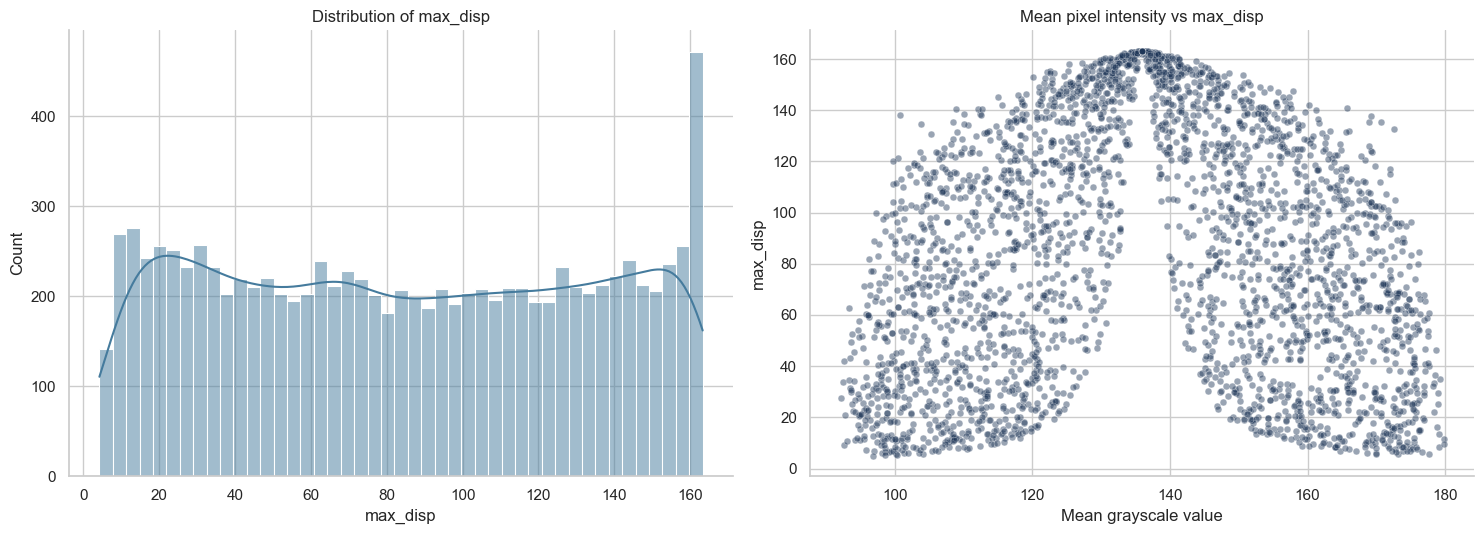

In [4]:
pixel_mean = X_img_raw.mean(axis=(1, 2, 3))
plot_df = df.copy()
plot_df["mean_pixel"] = pixel_mean
scatter_df = plot_df.sample(min(3000, len(plot_df)), random_state=SEED)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

sns.histplot(y, bins=45, kde=True, color="#457b9d", ax=axes[0])
axes[0].set_title(f"Distribution of {target_col}")
axes[0].set_xlabel(target_col)

sns.scatterplot(
    data=scatter_df,
    x="mean_pixel",
    y=target_col,
    alpha=0.45,
    s=24,
    color="#1d3557",
    ax=axes[1],
)
axes[1].set_title(f"Mean pixel intensity vs {target_col}")
axes[1].set_xlabel("Mean grayscale value")
axes[1].set_ylabel(target_col)

sns.despine(fig=fig)
plt.tight_layout()
plt.show()

### Sample Images (Visual Signal Check)

Before training, it helps to look at the actual input modality. A CNN sees local edges, gradients, and shapes, not the scalar columns in the CSV. By sampling a few images across the dataset, you can sanity-check orientation, contrast, and whether the target values seem visually diverse enough to justify a nonlinear image model.

This is not a statistical proof of learnability. It is a visual debugging step. If the images are blank, inverted, transposed, or all nearly identical, the model will struggle no matter how fancy the architecture looks.

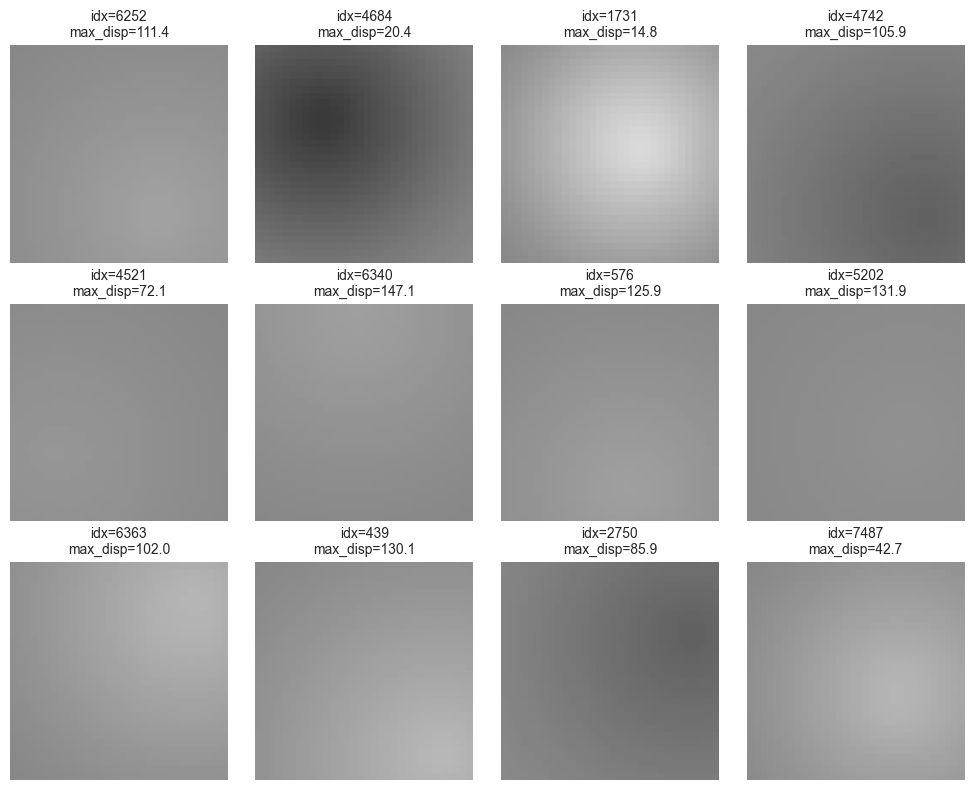

In [5]:
sample_positions = df.sample(12, random_state=SEED).index.to_list()
fig, axes = plt.subplots(3, 4, figsize=(10, 8))

for ax, pos in zip(axes.flat, sample_positions):
    ax.imshow(X_img_raw[pos].squeeze(), cmap="gray", vmin=0, vmax=255)
    ax.set_title(
        f"idx={int(df.loc[pos, index_col])}\n{target_col}={float(y.iloc[pos]):.1f}",
        fontsize=10,
    )
    ax.axis("off")

for ax in axes.flat[len(sample_positions):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

### PCA + t-SNE Projection (Structure in Image Space)

Now you project the image dataset into 2 dimensions using flattened pixel vectors. PCA is linear and tells you how much variance the leading axes summarize. t-SNE is nonlinear and focuses on local neighborhoods, often revealing structure that PCA can miss. These methods are for understanding geometry in the input space, not for direct performance measurement.

Because every pixel already shares the same grayscale scale, we use simple `[0, 1]` normalization for this visualization step. For t-SNE, we also reduce dimensionality first with PCA to keep the runtime demo-friendly.

References for deeper reading: [scikit-learn PCA User Guide](https://scikit-learn.org/stable/modules/decomposition.html#pca), [scikit-learn t-SNE User Guide](https://scikit-learn.org/stable/modules/manifold.html#t-sne), [Distill: How to Use t-SNE Effectively](https://distill.pub/2016/misread-tsne/).

PCA explained variance ratio -> PC1: 0.8127, PC2: 0.0859
PCA cumulative explained variance (PC1 + PC2): 0.8986


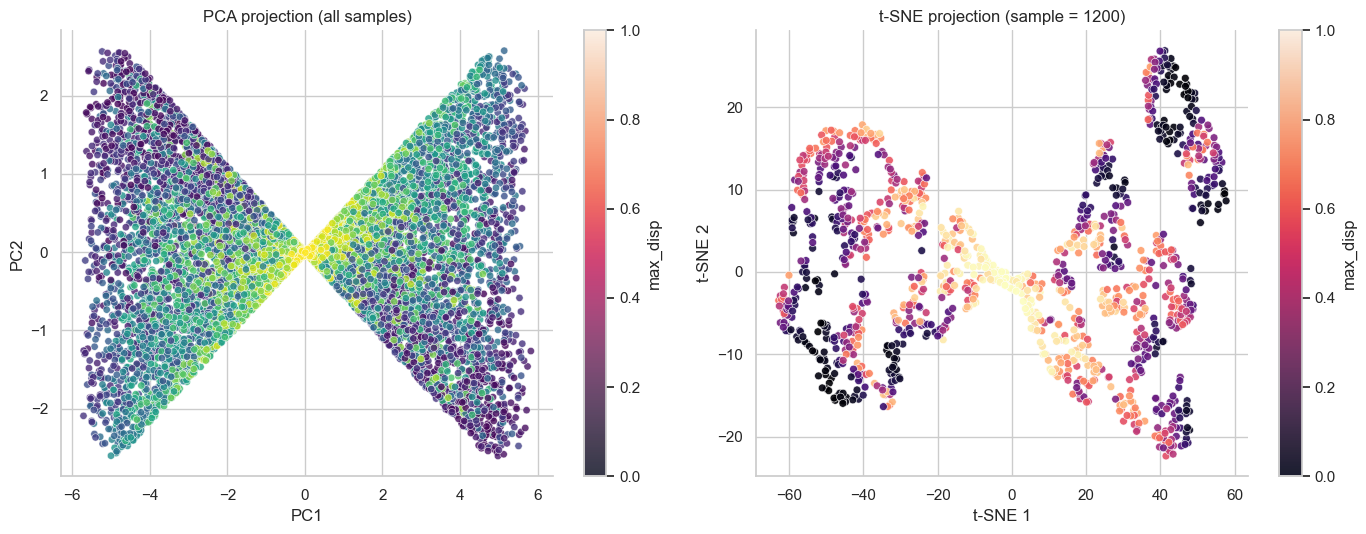

In [6]:
X_img_for_eda = X_img_raw.reshape(len(X_img_raw), -1) / 255.0

pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_img_for_eda)

evr = pca.explained_variance_ratio_
print(f"PCA explained variance ratio -> PC1: {evr[0]:.4f}, PC2: {evr[1]:.4f}")
print(f"PCA cumulative explained variance (PC1 + PC2): {evr.sum():.4f}")

tsne_sample_size = min(1200, len(X_img_for_eda))
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(X_img_for_eda), size=tsne_sample_size, replace=False)
X_tsne_input = X_img_for_eda[sample_idx]
y_tsne = y.iloc[sample_idx].reset_index(drop=True)

pca_pre_tsne = PCA(n_components=min(50, X_tsne_input.shape[1]), random_state=SEED)
X_tsne_reduced = pca_pre_tsne.fit_transform(X_tsne_input)

X_tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=SEED,
).fit_transform(X_tsne_reduced)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

pca_plot_df = pd.DataFrame({"PC1": X_pca[:, 0], "PC2": X_pca[:, 1], target_col: y})
sns.scatterplot(
    data=pca_plot_df,
    x="PC1",
    y="PC2",
    hue=target_col,
    palette="viridis",
    s=28,
    alpha=0.80,
    legend=False,
    ax=axes[0],
)
axes[0].set_title("PCA projection (all samples)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
fig.colorbar(axes[0].collections[0], ax=axes[0], label=target_col)

tsne_plot_df = pd.DataFrame({"t-SNE 1": X_tsne[:, 0], "t-SNE 2": X_tsne[:, 1], target_col: y_tsne})
sns.scatterplot(
    data=tsne_plot_df,
    x="t-SNE 1",
    y="t-SNE 2",
    hue=target_col,
    palette="magma",
    s=32,
    alpha=0.90,
    legend=False,
    ax=axes[1],
)
axes[1].set_title(f"t-SNE projection (sample = {tsne_sample_size})")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")
fig.colorbar(axes[1].collections[0], ax=axes[1], label=target_col)

sns.despine(fig=fig)
plt.tight_layout()
plt.show()

## 5. Train/Validation/Test Split

We split first, before any normalization used for training, so the validation and test sets stay truly unseen. This is the foundation of honest evaluation. In this beginner regression workflow we do not stratify on a continuous target; instead we keep the random seed fixed so comparisons remain reproducible.

The two-step split below gives approximately 70% train, 15% validation, and 15% test. Validation is used during model development (for early stopping and model choices), while test is reserved for the final one-time performance estimate.

References for stronger foundations: [scikit-learn: train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html), [Data leakage overview (scikit-learn common pitfalls)](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage).

In [7]:
sample_indices = df[index_col].to_numpy(dtype=int)
y_all = y.to_numpy(dtype="float32")

X_train_raw, X_temp_raw, y_train, y_temp, idx_train, idx_temp = train_test_split(
    X_img_raw,
    y_all,
    sample_indices,
    test_size=0.30,
    random_state=SEED,
)

X_val_raw, X_test_raw, y_val, y_test, idx_val, idx_test = train_test_split(
    X_temp_raw,
    y_temp,
    idx_temp,
    test_size=0.50,
    random_state=SEED,
)

print("Split sizes:")
print(f"Train: {X_train_raw.shape[0]} samples")
print(f"Val:   {X_val_raw.shape[0]} samples")
print(f"Test:  {X_test_raw.shape[0]} samples")

print()
print("Target mean by split:")
print(f"Train mean {target_col}: {y_train.mean():.3f}")
print(f"Val mean {target_col}:   {y_val.mean():.3f}")
print(f"Test mean {target_col}:  {y_test.mean():.3f}")

Split sizes:
Train: 7000 samples
Val:   1500 samples
Test:  1500 samples

Target mean by split:
Train mean max_disp: 84.923
Val mean max_disp:   86.700
Test mean max_disp:  82.529


## 6. Leakage-Safe Preprocessing (Image Normalization)

CNNs train more reliably when pixel values are on a compact, stable scale. Here we use the simplest common normalization rule for grayscale images: divide by 255 so values fall in `[0, 1]`. This is the image analogue of making the input scale friendlier for optimization.

Unlike the tabular MLP notebook, we are not fitting a `StandardScaler` here. Pixels already share the same measurement range, so plain normalization is a clean beginner default. The quick diagnostics at the end of the cell act as a sanity check that the tensors and flattened baseline arrays are ready.

In [8]:
X_train = X_train_raw.astype("float32") / 255.0
X_val = X_val_raw.astype("float32") / 255.0
X_test = X_test_raw.astype("float32") / 255.0

X_train_flat = X_train.reshape(len(X_train), -1)
X_val_flat = X_val.reshape(len(X_val), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

print("Normalized image tensors ready.")
print(f"Train tensor shape: {X_train.shape}")
print(f"Val tensor shape:   {X_val.shape}")
print(f"Test tensor shape:  {X_test.shape}")
print(f"Normalized pixel range (train): {X_train.min():.3f} to {X_train.max():.3f}")
print(f"Flattened baseline shape: {X_train_flat.shape}")

Normalized image tensors ready.
Train tensor shape: (7000, 32, 32, 1)
Val tensor shape:   (1500, 32, 32, 1)
Test tensor shape:  (1500, 32, 32, 1)
Normalized pixel range (train): 0.188 to 0.878
Flattened baseline shape: (7000, 1024)


## 7. Baseline Model (Ridge on Flattened Pixels)

A baseline still matters for image regression. Before using convolutional layers, ask whether a simple linear model on flattened pixels already explains a meaningful amount of signal. We use **Ridge regression** rather than plain `LinearRegression` because images create many correlated pixel features, and a small L2 penalty usually gives a more stable linear baseline.

If the CNN does not beat this baseline, then the spatial inductive bias of convolution is not helping enough yet. That could mean the task is mostly linear, the CNN is under-tuned, or the images do not carry as much signal as expected.

In [9]:
ridge_baseline = Ridge(alpha=1.0)
ridge_baseline.fit(X_train_flat, y_train)

ridge_val_pred = ridge_baseline.predict(X_val_flat)

ridge_val_mae = mean_absolute_error(y_val, ridge_val_pred)
ridge_val_rmse = root_mean_squared_error(y_val, ridge_val_pred)
ridge_val_r2 = r2_score(y_val, ridge_val_pred)

print("Validation metrics - Ridge baseline (flattened pixels)")
print(f"MAE : {ridge_val_mae:.4f}")
print(f"RMSE: {ridge_val_rmse:.4f}")
print(f"R^2 : {ridge_val_r2:.4f}")

Validation metrics - Ridge baseline (flattened pixels)
MAE : 41.4861
RMSE: 47.4767
R^2 : -0.0046


## 8. Convolutional Neural Network Model (CNN)

Now we train a small CNN for continuous prediction. The main idea is to let the model learn local spatial filters before combining them into a final scalar output. Compared with a flattened linear model, convolution gives the network a stronger bias toward local patterns, edges, and repeated shapes in the rasterized geometry.

Here we train with **MSE loss** and track **MAE** and **RMSE** so you can compare different error views side by side.

- **MAE (Mean Absolute Error)**: average absolute mistake size in the original target units.
- **RMSE (Root Mean Squared Error)**: penalizes larger mistakes more strongly than MAE but still stays in the original units.
- **MSE (Mean Squared Error)**: the optimization objective here; it pushes the model to care strongly about large misses.

Early stopping is enabled to prevent over-training once validation loss stops improving. This is a practical regularization pattern you will use often in real workflows.

References for model mechanics: [Keras Conv2D](https://keras.io/api/layers/convolution_layers/convolution2d/), [Keras MaxPooling2D](https://keras.io/api/layers/pooling_layers/max_pooling2d/), [Keras Sequential API](https://keras.io/guides/sequential_model/), [Keras EarlyStopping](https://keras.io/api/callbacks/early_stopping/).

In [10]:
model = keras.Sequential([
    keras.layers.Input(shape=X_train.shape[1:]),
    keras.layers.Conv2D(16, kernel_size=3, padding="same", activation="relu"),
    keras.layers.MaxPooling2D(pool_size=2),
    keras.layers.Conv2D(32, kernel_size=3, padding="same", activation="relu"),
    keras.layers.MaxPooling2D(pool_size=2),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(1),
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=4e-3),
    loss=keras.losses.MeanSquaredError(),
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.RootMeanSquaredError(name="rmse"),
    ],
)

early_stop_patience = 32
reduce_lr_patience = max(1, early_stop_patience // 4)

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=early_stop_patience,
    restore_best_weights=True,
    min_delta=1e-3,
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=reduce_lr_patience,
    min_lr=1e-6,
    verbose=1,
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=4096,
    batch_size=128,
    callbacks=[early_stopping, reduce_lr],
    verbose=1,
)

print(f"Training finished after {len(history.history['loss'])} epochs.")


Epoch 1/4096
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4596.9497 - mae: 55.5063 - rmse: 66.8906 - val_loss: 2483.6941 - val_mae: 42.9890 - val_rmse: 49.8367 - learning_rate: 0.0040
Epoch 2/4096
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2439.1387 - mae: 42.6918 - rmse: 49.3864 - val_loss: 2395.8171 - val_mae: 42.4413 - val_rmse: 48.9471 - learning_rate: 0.0040
Epoch 3/4096
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2393.3782 - mae: 42.3572 - rmse: 48.9207 - val_loss: 2347.8684 - val_mae: 42.1284 - val_rmse: 48.4548 - learning_rate: 0.0040
Epoch 4/4096
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2351.6838 - mae: 42.0537 - rmse: 48.4925 - val_loss: 2324.7908 - val_mae: 41.9313 - val_rmse: 48.2161 - learning_rate: 0.0040
Epoch 5/4096
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2303.1128 - mae: 41.7260 - rmse: 47.9893 - val_loss: 2230.1558 - val_mae: 41.1461 - val_rmse: 47.2245 - learning_rate: 0.0040
Epoch 6/4096
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2132.1943

## 9. Training Curves

Training curves help you diagnose model behavior beyond a single metric value. If training loss drops while validation loss rises, you are likely overfitting. If both losses stay high and flat, the model may be underfitting or learning too slowly.

Because this model trains with **MSE** and tracks **MAE** and **RMSE**, we can inspect each view of the error during optimization. The loss curves show the objective the optimizer is minimizing, while the metric curves show prediction error in more interpretable forms. Focus on trend shape rather than one noisy epoch.

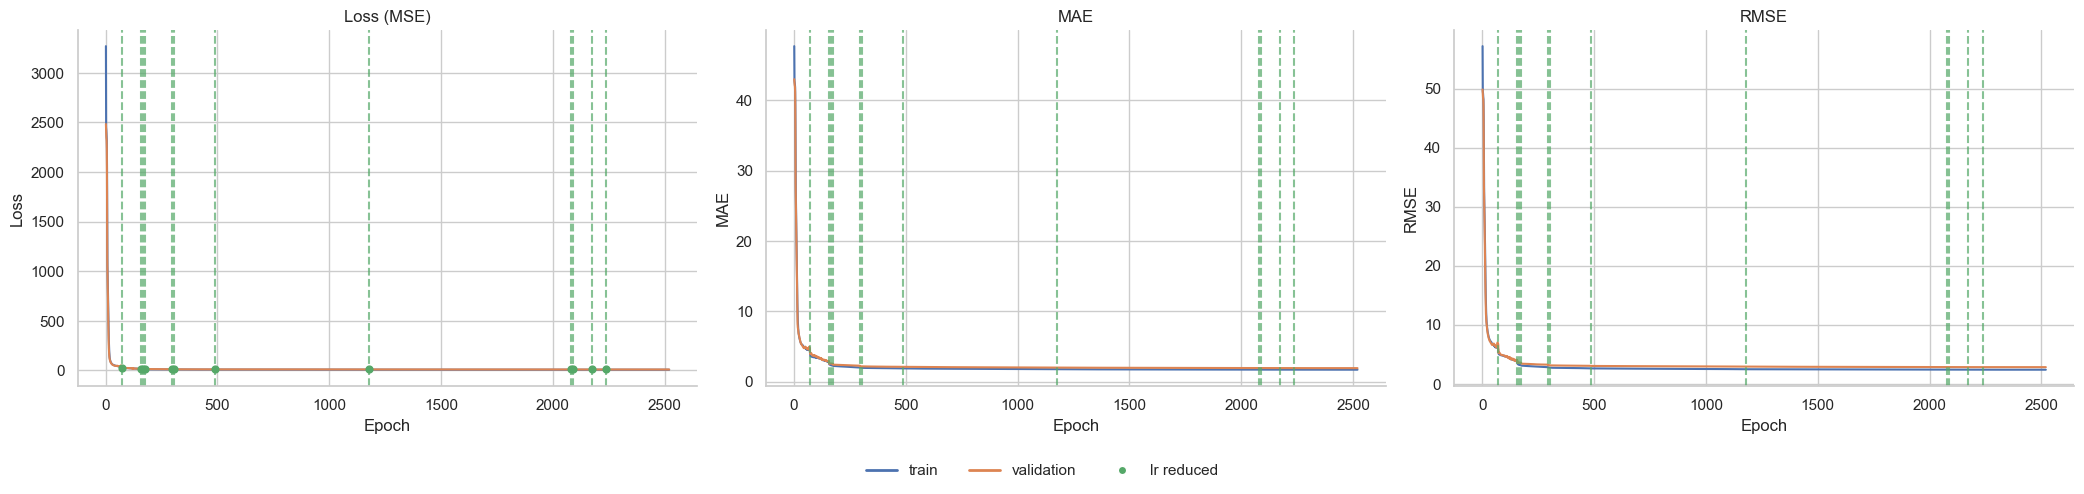

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(21, 5))
axes = axes.ravel()

history_df = pd.DataFrame(history.history)
history_df["epoch"] = np.arange(1, len(history_df) + 1)

lr_drop_epochs = []
if "learning_rate" in history_df.columns:
    lr_drop_epochs = history_df.loc[
        history_df["learning_rate"].diff().fillna(0) < 0,
        "epoch",
    ].tolist()

sns.lineplot(data=history_df, x="epoch", y="loss", ax=axes[0], label="train_loss")
sns.lineplot(data=history_df, x="epoch", y="val_loss", ax=axes[0], label="val_loss")
axes[0].set_title("Loss (MSE)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

sns.lineplot(data=history_df, x="epoch", y="mae", ax=axes[1], label="train_mae")
sns.lineplot(data=history_df, x="epoch", y="val_mae", ax=axes[1], label="val_mae")
axes[1].set_title("MAE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE")

sns.lineplot(data=history_df, x="epoch", y="rmse", ax=axes[2], label="train_rmse")
sns.lineplot(data=history_df, x="epoch", y="val_rmse", ax=axes[2], label="val_rmse")
axes[2].set_title("RMSE")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("RMSE")

for ax in axes:
    for epoch in lr_drop_epochs:
        ax.axvline(epoch, color=sns.color_palette()[2], linestyle="--", alpha=0.7, linewidth=1.5)

lr_handle = None
if lr_drop_epochs:
    drop_mask = history_df["epoch"].isin(lr_drop_epochs)
    lr_handle = axes[0].scatter(
        history_df.loc[drop_mask, "epoch"],
        history_df.loc[drop_mask, "val_loss"],
        color=sns.color_palette()[2],
        s=24,
        zorder=5,
        label="lr reduced",
    )

for ax in axes:
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()

handles = [
    plt.Line2D([0], [0], color=sns.color_palette()[0], lw=2, label="train"),
    plt.Line2D([0], [0], color=sns.color_palette()[1], lw=2, label="validation"),
]
if lr_handle is not None:
    handles.append(
        plt.Line2D(
            [0], [0],
            marker="o",
            color="w",
            markerfacecolor=sns.color_palette()[2],
            markersize=6,
            label="lr reduced",
        )
    )

fig.legend(
    handles=handles,
    loc="lower center",
    ncol=len(handles),
    frameon=False,
    bbox_to_anchor=(0.5, 0),
)

sns.despine(fig=fig)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

## 10. Final Evaluation on the Test Set

Only now do we touch the test set. This is your final, unbiased checkpoint after all modeling decisions are complete. We evaluate with multiple metrics because each one captures a different behavior:

- **MAE**: average absolute error in target units.
- **RMSE**: root-mean-square error, which penalizes larger misses more strongly than MAE.
- **R^2**: explained variance relative to a mean-only predictor.

In this notebook you compare the CNN against a Ridge baseline on flattened pixels. That is a strong sanity check for image data: if the CNN beats the linear pixel baseline, then local spatial structure is likely helping.

The prediction-vs-actual plot should cluster around the diagonal if the model is well calibrated. The residual plot should keep most points centered around zero, and its LOWESS trend should stay fairly flat rather than bending into a strong curve. The residual histogram should also be centered near zero; strong skew or very heavy tails suggest systematic bias or unresolved structure.

Test metrics - CNN
MAE : 1.7953
RMSE: 2.5511
R^2 : 0.9973

Test metrics - Ridge baseline
MAE : 42.8698
RMSE: 48.7507
R^2 : -0.0013


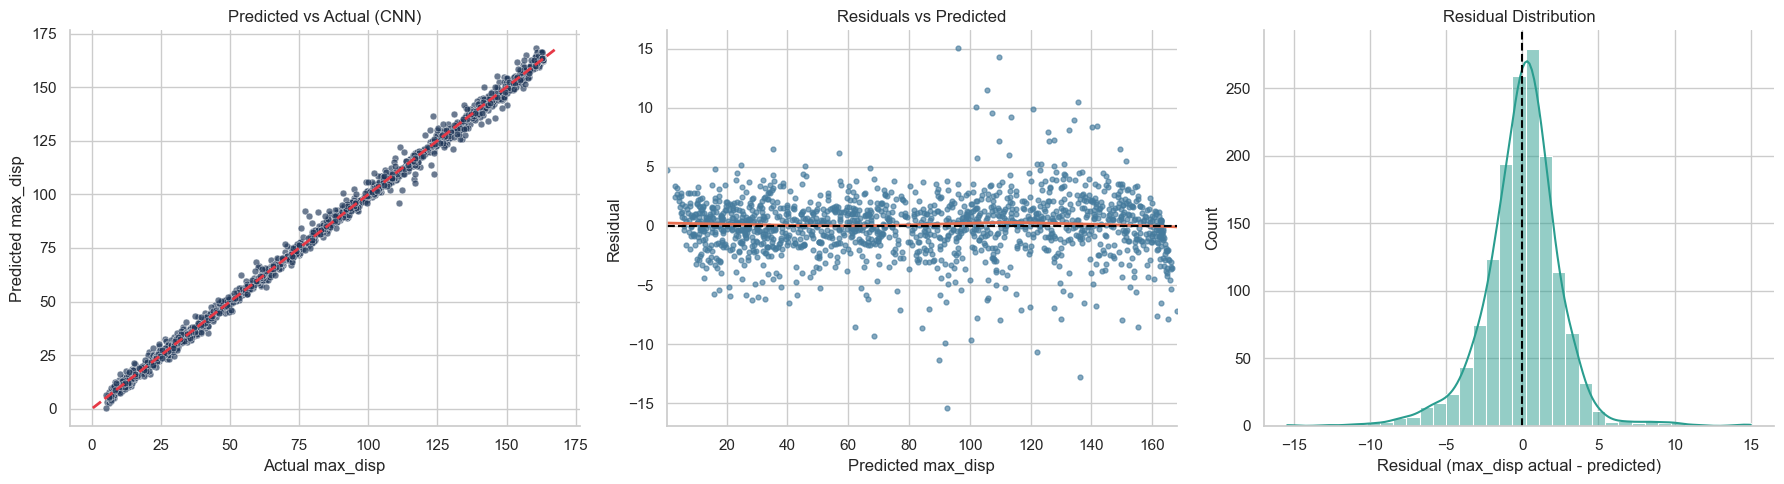

In [12]:
cnn_test_pred = model.predict(X_test, verbose=0).ravel()
ridge_test_pred = ridge_baseline.predict(X_test_flat)

cnn_mae = mean_absolute_error(y_test, cnn_test_pred)
cnn_rmse = root_mean_squared_error(y_test, cnn_test_pred)
cnn_r2 = r2_score(y_test, cnn_test_pred)

ridge_mae = mean_absolute_error(y_test, ridge_test_pred)
ridge_rmse = root_mean_squared_error(y_test, ridge_test_pred)
ridge_r2 = r2_score(y_test, ridge_test_pred)

print("Test metrics - CNN")
print(f"MAE : {cnn_mae:.4f}")
print(f"RMSE: {cnn_rmse:.4f}")
print(f"R^2 : {cnn_r2:.4f}")

print()
print("Test metrics - Ridge baseline")
print(f"MAE : {ridge_mae:.4f}")
print(f"RMSE: {ridge_rmse:.4f}")
print(f"R^2 : {ridge_r2:.4f}")

y_test_vals = np.asarray(y_test).reshape(-1)
pred_vals = np.asarray(cnn_test_pred).reshape(-1)
residuals = y_test_vals - pred_vals

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(x=y_test_vals, y=pred_vals, alpha=0.65, s=24, color="#1d3557", ax=axes[0])
min_v = min(y_test_vals.min(), pred_vals.min())
max_v = max(y_test_vals.max(), pred_vals.max())
sns.lineplot(x=[min_v, max_v], y=[min_v, max_v], ax=axes[0], color="#e63946", linestyle="--", linewidth=2)
axes[0].set_title("Predicted vs Actual (CNN)")
axes[0].set_xlabel(f"Actual {target_col}")
axes[0].set_ylabel(f"Predicted {target_col}")

sns.residplot(
    x=pred_vals,
    y=y_test_vals,
    lowess=True,
    ax=axes[1],
    scatter_kws={"alpha": 0.65, "s": 12, "color": "#457b9d"},
    line_kws={"color": "#e76f51", "linewidth": 2},
)
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set_title("Residuals vs Predicted")
axes[1].set_xlabel(f"Predicted {target_col}")
axes[1].set_ylabel("Residual")

sns.histplot(residuals, bins=35, kde=True, color="#2a9d8f", ax=axes[2])
axes[2].axvline(0, color="black", linestyle="--")
axes[2].set_title("Residual Distribution")
axes[2].set_xlabel(f"Residual ({target_col} actual - predicted)")

sns.despine(fig=fig)
plt.tight_layout()
plt.show()

## 11. Save Trained Artifacts

Save the trained CNN and the metadata needed for inference. Because this image pipeline only applies fixed `[0, 1]` normalization by dividing by 255, there is no fitted scaler object to save. The important pieces are the `.keras` model and a small metadata JSON describing the dataset, image shape, and evaluation results.

In [13]:
if Path("inclass_examples").exists():
    artifacts_dir = Path("inclass_examples/artifacts/cnn_regression")
else:
    artifacts_dir = Path("../artifacts/cnn_regression")

artifacts_dir.mkdir(parents=True, exist_ok=True)

import json

model_path = artifacts_dir / "maxDisplacement_cnn_regressor.keras"
metadata_path = artifacts_dir / "maxDisplacement_cnn_regressor_metadata.json"

model.save(model_path)

metadata = {
    "source_csv": str(CSV_PATH),
    "image_dir": str(DATA_DIR),
    "target_col": target_col,
    "index_col": index_col,
    "image_shape": [int(v) for v in X_train.shape[1:]],
    "normalization": "divide_by_255",
    "baseline": "Ridge(alpha=1.0) on flattened pixels",
    "seed": SEED,
    "test_metrics": {
        "cnn_mae": float(cnn_mae),
        "cnn_rmse": float(cnn_rmse),
        "cnn_r2": float(cnn_r2),
        "ridge_mae": float(ridge_mae),
        "ridge_rmse": float(ridge_rmse),
        "ridge_r2": float(ridge_r2),
    },
}
metadata_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

print(f"Saved model to: {model_path.resolve()}")
print(f"Saved metadata to: {metadata_path.resolve()}")

Saved model to: C:\Users\Ozguc\Documents\GitHub\CMDO-ML\inclass_examples\artifacts\cnn_regression\maxDisplacement_cnn_regressor.keras
Saved metadata to: C:\Users\Ozguc\Documents\GitHub\CMDO-ML\inclass_examples\artifacts\cnn_regression\maxDisplacement_cnn_regressor_metadata.json


## 12. Mini Exercises

1. Add a third convolution block and compare whether validation MAE improves consistently or only briefly before overfitting.
2. Replace `Flatten()` with `GlobalAveragePooling2D()` and explain how the parameter count and test performance change.
3. Try a slightly stronger or weaker Ridge baseline (`alpha=0.1`, `1.0`, `10.0`) and compare it against the CNN.
4. Build a multi-input model that combines the image with a few scalar columns from `scalar_feature_df` (for example, the first three entries in `scalar_feature_cols`), then compare it against the image-only CNN.